In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Importação de Dados

Neste ponto importamos os dados obtidos com o script `coleta_dados.py` e observamos algumas informações básicas do dataset, pode-se observar que há um número elevado de linhas com dados nulos.

In [59]:
df = pd.read_csv("../data/dados_paises_com_regiao.csv")
df.sort_values(by=['Country_Code', 'Year'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 1302 entries, 582 to 1301
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country_Name             1302 non-null   str    
 1   Country_Code             1302 non-null   str    
 2   Region                   1302 non-null   str    
 3   Income_Group             1302 non-null   str    
 4   Year                     1302 non-null   int64  
 5   Internet_Usage_Pct       919 non-null    float64
 6   GDP_Per_Capita_PPP       982 non-null    float64
 7   Broadband_Subscriptions  931 non-null    float64
 8   GDP_USD                  1024 non-null   float64
 9   Secure_Servers           1074 non-null   float64
dtypes: float64(5), int64(1), str(4)
memory usage: 177.6 KB


# Interpolação de Dados

Para resolver o problema dos dados nulos será usado a técnica de interpolação linear aplicada trés vezes com agrupamentos diferentes, primeiro agrupamos observações do próprio país, depois agrupamos as observações de um ano de países da mesma região e grupo de renda, e por último agrupamos apenas por ano e região. As interpolações foram aplicadas nos agrupamentos na ordem que eles foram mencionados anteriormente para garantir o maior nível de precisão.

In [60]:
indicadores = {
    'Internet_Usage_Pct': 'Uso de Internet',
    'GDP_Per_Capita_PPP': 'PIB per Capita',
    'Broadband_Subscriptions': 'Banda Larga Fixa',
    'GDP_USD': 'Tamanho Economia PIB',
    'Secure_Servers': 'Infra Servidores B2B'
}

df_interpolado = df

for col in indicadores.keys():
    # O limit_direction='both' garante que ele preencha tanto buracos no meio, 
    # quanto buracos nas pontas (usando o primeiro ou último valor disponível)
    df_interpolado[col] = df_interpolado.groupby('Country_Code')[col].transform(
        lambda x:  x.interpolate(method='linear', limit_direction='both')
    )

for col in indicadores.keys():
    # O limit_direction='both' garante que ele preencha tanto buracos no meio, 
    # quanto buracos nas pontas (usando o primeiro ou último valor disponível)
    df_interpolado[col] = df_interpolado.groupby(['Region', 'Income_Group', 'Year'])[col].transform(
        lambda x:  x.interpolate(method='linear', limit_direction='both')
    )

for col in indicadores.keys():
    # O limit_direction='both' garante que ele preencha tanto buracos no meio, 
    # quanto buracos nas pontas (usando o primeiro ou último valor disponível)
    df_interpolado[col] = df_interpolado.groupby(['Region', 'Year'])[col].transform(
        lambda x:  x.interpolate(method='linear', limit_direction='both')
    )

df_interpolado.info()

<class 'pandas.DataFrame'>
Index: 1302 entries, 582 to 1301
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country_Name             1302 non-null   str    
 1   Country_Code             1302 non-null   str    
 2   Region                   1302 non-null   str    
 3   Income_Group             1302 non-null   str    
 4   Year                     1302 non-null   int64  
 5   Internet_Usage_Pct       1302 non-null   float64
 6   GDP_Per_Capita_PPP       1302 non-null   float64
 7   Broadband_Subscriptions  1302 non-null   float64
 8   GDP_USD                  1302 non-null   float64
 9   Secure_Servers           1302 non-null   float64
dtypes: float64(5), int64(1), str(4)
memory usage: 177.6 KB


# Exploração dos Dados

A seguir estão alguns gráficos gerados a partir dos dados interpolados, com uma análise inicial dos mesmos

## Tabela de Medidas de Distribuição e Dispersão

In [61]:
df_interpolado.describe()

,Year,Internet_Usage_Pct,GDP_Per_Capita_PPP,Broadband_Subscriptions,GDP_USD,Secure_Servers
count,1302.000000,1302.000000,1302.000000,1302.000000,1.302000e+03,1.302000e+03
mean,2022.500000,69.957681,30179.233433,17.761733,4.772333e+11,2.688010e+04
std,1.708481,25.677412,28959.200789,15.845742,2.212189e+12,1.386403e+05
min,2020.000000,6.430100,958.135599,0.000000,5.174659e+07,7.652189e-02
25%,2021.000000,54.762899,6911.582542,2.078773,7.958735e+09,9.990321e+01
50%,2022.500000,79.218294,19674.947221,14.046493,3.181060e+10,8.100147e+02
75%,2024.000000,89.825070,47659.961497,31.281352,2.178198e+11,1.172000e+04
max,2025.000000,100.000000,155941.288211,60.974767,2.875096e+13,3.262663e+06


## Mapa de Calor

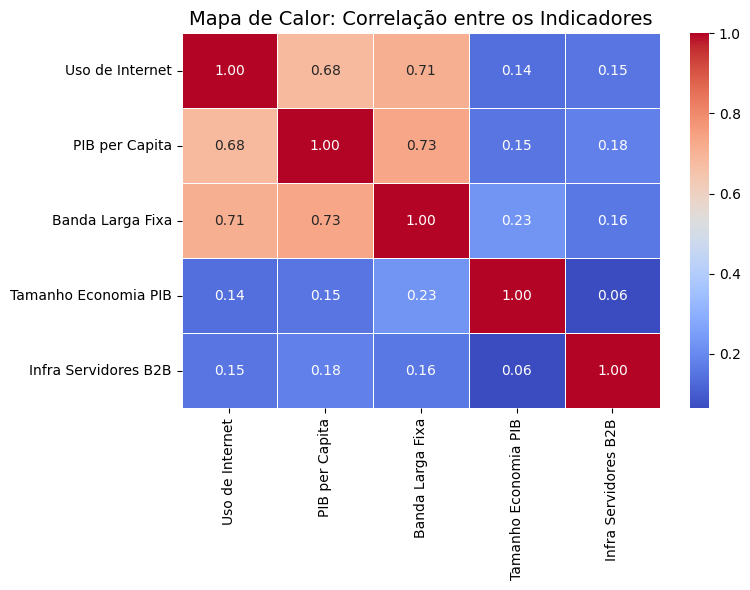

In [62]:
plt.figure(figsize=(8, 6))
corr_map = df_interpolado[indicadores.keys()].corr()
corr_map = corr_map.rename(columns=indicadores, index=indicadores)

sns.heatmap(corr_map, 
            annot=True,          # Mostra os números dentro dos quadrados
            cmap='coolwarm',     # Cores (azul para negativo, vermelho para positivo)
            fmt=".2f",           # Formata para 2 casas decimais
            linewidths=0.5)

plt.title("Mapa de Calor: Correlação entre os Indicadores", fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

## Boxplot

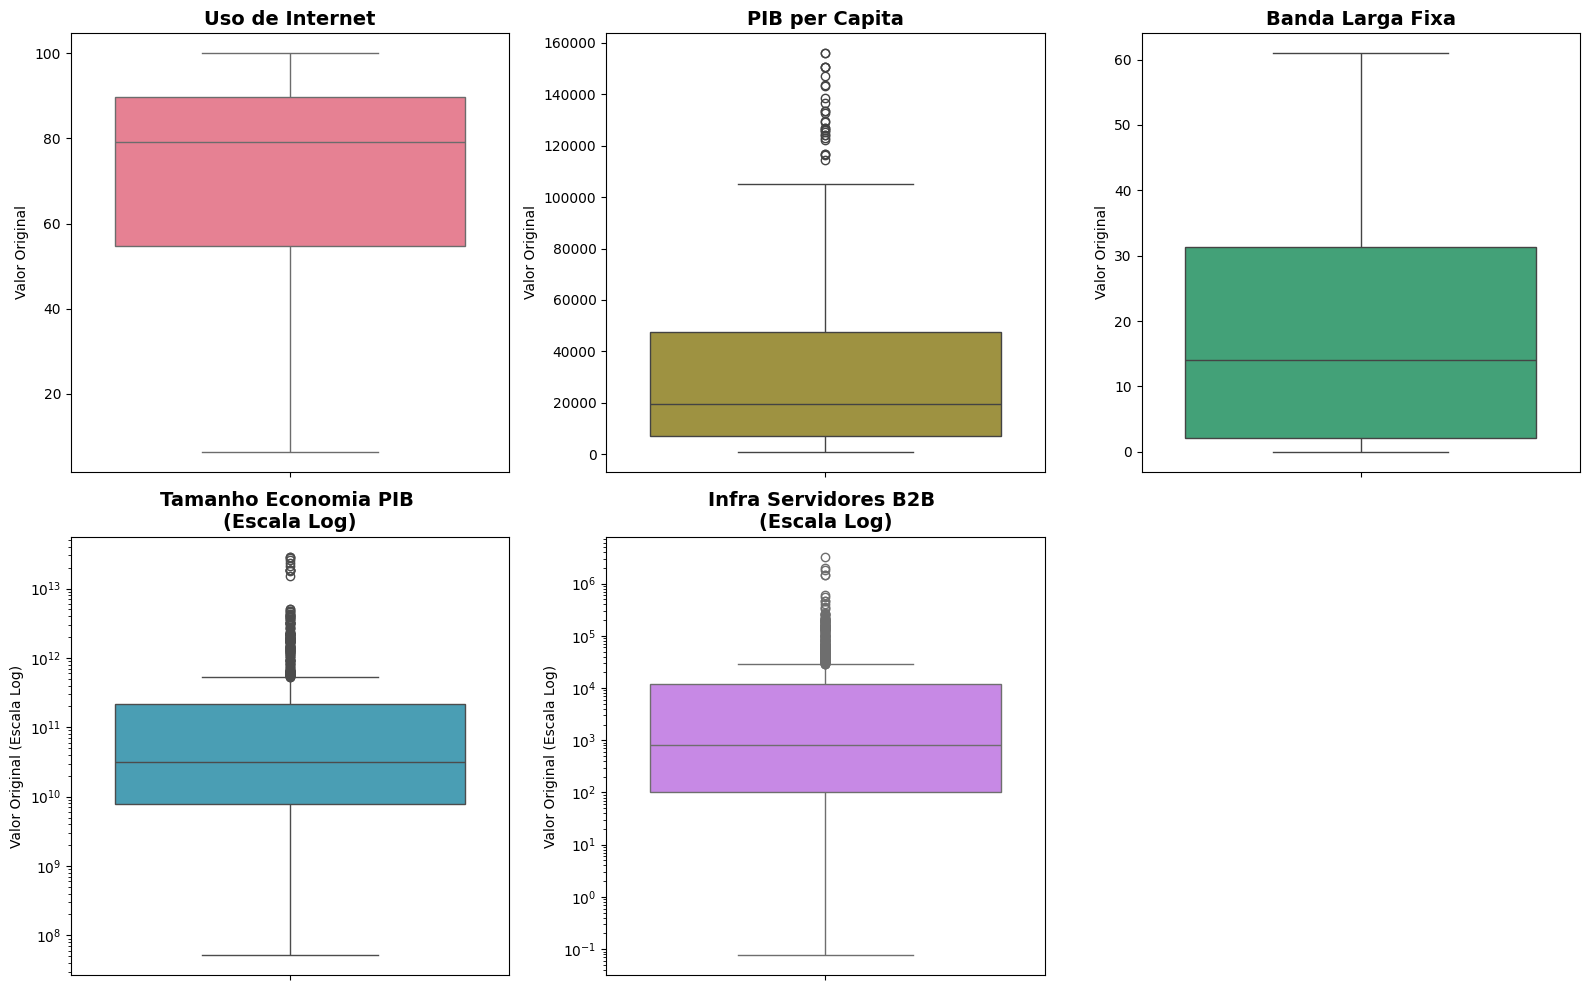

In [63]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

axes = axes.flatten()

cores = sns.color_palette("husl", len(indicadores))

for i, (col_tecnica, nome_apresentacao) in enumerate(indicadores.items()):
    sns.boxplot(y=df[col_tecnica], ax=axes[i], color=cores[i])
    
    axes[i].set_title(nome_apresentacao, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Valor Original')
    
    if col_tecnica in ['GDP_USD', 'Secure_Servers']:
        axes[i].set_yscale('log')
        axes[i].set_ylabel('Valor Original (Escala Log)')
        axes[i].set_title(nome_apresentacao + " \n(Escala Log)", fontsize=14, fontweight='bold')

fig.delaxes(axes[5])

plt.tight_layout()

plt.show()
plt.close()